# 5. 深度学习计算

> 本节对应《动手学深度学习（PyTorch 版）》第 5 章第 1 节：
> [5.1 层和块](https://zh-v2.d2l.ai/chapter_deep-learning-computation/model-construction.html)

到目前为止，我们一直在"使用"现成的模型：把样本喂进 `nn.Linear`、把它们串成 `nn.Sequential`、再交给优化器训练。但真正从事深度学习，必须理解并**亲手组装**模型。本章关注深度学习计算的关键组件，尤其是**构建模型的底层机制**。

本章路线图：

| 小节 | 主题 | 解决的问题 |
| --- | --- | --- |
| 5.1 层和块 | 块（block）抽象 | 如何用任意代码块组装网络 |
| 5.2 参数管理 | 参数访问 / 初始化 / 共享 | 参数存在哪、怎么改 |
| 5.3 延后初始化 | 输入维度自动推断 | 为什么定义层时不用写输入维度 |
| 5.4 自定义层 | 从零构建层 | 如何写一个带参数的新层 |
| 5.5 读写文件 | 存储 / 加载模型 | 权重如何保存与恢复 |
| 5.6 GPU | 设备管理 | 计算如何搬到显卡上 |


## 5.1 层和块

对于"单一输入、单一输出"的层，我们脑中有一个"神经元"的直观图像。但对于**多输出通道、任意数量输入**的卷积层、具有多个中间变量的层，以及需要"保留状态"（如 RNN 隐状态）的层，这个图像就不够用了。本节核心思想：

> **不要把网络看成一堆层的线性堆叠，而要看成一棵由"块"递归组成的树。**

### 1. 为什么要"块"

**块（block）** 是一个抽象概念：它可以描述

- 单个层；
- 由多个层组成的一个组件；
- 甚至整个模型本身。

块的好处在于**组合（composition）**：小块拼成大块，大块再拼成更大的块，这种**递归组合**正是设计神经网络架构的基本手段（对应设计模式中的**组合模式**）。

三个层级的对比：

| 层级 | 典型对象 | 可学习参数 | 由谁构成 |
| --- | --- | --- | --- |
| 神经元 | 一个带权重的加权和 + 激活 | $w, b$ | 输入标量 |
| 层 | `nn.Linear`、`nn.Conv2d` | 权重矩阵 + 偏置 | 一组神经元 |
| 块 / 模型 | `nn.Sequential`、整个网络 | 其所有子块的参数 | 层或其他块 |

现实中的模型远不止"几层串起来"。例如 ResNet-152 有数百个块、上千层，其重复结构（残差块）正是靠"块"的复用实现的。如果每次都要手写 152 层的 forward，既不可能也不可靠——**必须有一套机制，让我们像搭积木一样组合代码块**。

实际上，程序员做的事情完全一致：从"单个神经元"到"层"再到"整个模型"，都是同一套接口的递归实现。下图展示了这种递归组合结构（图 5.1.1）：

![图5.1.1 多个层被组合成块，形成更大的模型](src/blocks.svg)

先回顾一下 `nn.Sequential` 的用法，它是 PyTorch 提供的最简单的"块"：

In [1]:
import torch
from torch import nn
from torch.nn import functional as F

# nn.Sequential内部按顺序登记若干层，并在 forward 中依次调用它们
net = nn.Sequential(nn.Linear(20, 256), nn.ReLU(), nn.Linear(256, 10))

X = torch.rand(2, 20)  # 2个样本，每个样本20维
net(X)  # 输出形状(2,10)

tensor([[ 0.0049,  0.0062,  0.0354, -0.0353,  0.0041,  0.0094,  0.0298,  0.0385,
         -0.0857, -0.0641],
        [ 0.0546,  0.0704, -0.0136, -0.0422,  0.0541, -0.1243, -0.0481,  0.0736,
         -0.1681, -0.0264]], grad_fn=<AddmmBackward0>)

把这个 MLP 的数学形式写清楚。设输入为 $\mathbf{X}\in\mathbb{R}^{n\times 20}$，隐藏层权重 $\mathbf{W}^{(1)}\in\mathbb{R}^{20\times 256}$、偏置 $\mathbf{b}^{(1)}\in\mathbb{R}^{1\times 256}$，输出层权重 $\mathbf{W}^{(2)}\in\mathbb{R}^{256\times 10}$、偏置 $\mathbf{b}^{(2)}\in\mathbb{R}^{1\times 10}$，则前向传播为：

$$
\mathbf{H} = \phi\left(\mathbf{X}\mathbf{W}^{(1)} + \mathbf{b}^{(1)}\right), \qquad
\mathbf{O} = \mathbf{H}\mathbf{W}^{(2)} + \mathbf{b}^{(2)}
$$

其中 $\phi$ 是激活函数（这里是 ReLU）。注意批量大小 $n$ 从未在代码中出现——PyTorch 的运算天然按批量广播，这正是"块"抽象带来的便利。

可学习参数量核算：

$$
P = \underbrace{(20\times 256 + 256)}_{\text{隐藏层 } 5376} + \underbrace{(256\times 10 + 10)}_{\text{输出层 } 2570} = 7946
$$

一般规律：一个线性层的参数量 $P = in \times out + out$（偏置跟随输出维度）。

In [2]:
# 验证参数量：逐层统计+汇总
total = 0
for name, param in net.named_parameters():
    print(name, tuple(param.shape), "=", param.numel())
    total += param.numel()
print("总参数量:", total)

0.weight (256, 20) = 5120
0.bias (256,) = 256
2.weight (10, 256) = 2560
2.bias (10,) = 10
总参数量: 7946


### 2. 自定义块

每个块（即 `nn.Module` 的子类）必须提供 5 个基本功能：

1. **把输入作为前向传播的输入**：接收数据 $\mathbf{X}$；
2. **产生输出**：前向传播的输出，形状通常与输入不同；
3. **计算输出关于输入的梯度**：由自动微分（autograd）系统自动完成，无需手写；
4. **存储并访问前向传播所需的参数**：例如 MLP 中的 $\mathbf{W}^{(1)}, \mathbf{b}^{(1)}, \mathbf{W}^{(2)}, \mathbf{b}^{(2)}$；
5. **根据需要初始化模型参数**：详见 5.2 节。

下例用 `nn.Module` 从零实现一个与上面 `net` 等价的 MLP。注意：`nn.Module` 本身**没有 forward 逻辑**，每个子类必须自己定义 `forward`。

In [3]:
class MLP(nn.Module):
    # 用模型参数声明层。这里声明了两个全连接层
    def __init__(self):
        # 调用MLP的父类 Module的构造函数来执行必要的初始化
        # 这样在类实例化时也可以制定其他函数参数
        super().__init__()
        self.hidden = nn.Linear(20, 256)  # 隐藏层
        self.out = nn.Linear(256, 10)  # 输出层

    # 定义模型的前向传播，及如何根据输入X返回所需的模型输出
    def forward(self, X):
        return self.out(F.relu(self.hidden(X)))


net = MLP()
net(X)  # 与nn.Sequential版本输出等价

tensor([[ 0.0401, -0.0460, -0.0735,  0.0594,  0.0757, -0.0687, -0.0664,  0.0173,
          0.1850,  0.0249],
        [ 0.0483, -0.0509,  0.0343, -0.0140,  0.0604, -0.0602,  0.0543, -0.0298,
          0.2804, -0.0972]], grad_fn=<AddmmBackward0>)

#### 原理：为什么这样写就能工作？

**① `super().__init__()` 做了什么？**
它初始化 `nn.Module` 的内部状态，最关键的是创建 `self._modules = OrderedDict()`——一个**有序字典**，专门存放子模块。忘了调用它，注册机制会直接报错：`AttributeError: cannot assign module before Module.__init__() call`。

**② `self.hidden = nn.Linear(20, 256)` 为什么不需要显式"注册"？**
因为 `nn.Module` 重写了 `__setattr__`。当给实例属性赋值一个 `nn.Module`（或 `nn.Parameter`）对象时，它不会进普通的 `__dict__`，而是被自动登记进 `self._modules`（参数张量则进 `self._parameters`）。这就是 PyTorch "自动注册"的魔法。

**③ 由此形成 Module 树：**

```text
MLP
├── hidden : Linear(20 → 256)
└── out    : Linear(256 → 10)
```

整棵树是**递归**的：任何 `nn.Module` 都可以作为另一个 `nn.Module` 的子节点。PyTorch 的很多核心功能就是沿这棵树递归实现的：

- `net.parameters()`：深度优先遍历树，收集所有 `_parameters`（优化器靠它拿到全部可训练参数）；
- `net.state_dict()` / `net.load_state_dict()`：沿树拼接 / 回填参数字典（保存与恢复模型）；
- `net.to(device)`：沿树把每个参数张量搬到指定设备；
- `net.train()` / `net.eval()`：沿树设置每个子模块的训练 / 评估标志。

**④ `net(X)` 和 `net.forward(X)` 有什么区别？**
`nn.Module` 定义了 `__call__`，`net(X)` 实际执行 `net.__call__(X)` → `_call_impl(X)`：先触发注册的 hooks（钩子），再调用你的 `forward`。所以**永远直接写 `net(X)`**——写 `net.forward(X)` 会绕过钩子机制。

In [4]:
# 观察Module树的效果：参数名自动带上“父块.子块”的路径前缀
for name, param in net.named_parameters():
    print(f"{name:15s} -> {tuple(param.shape)}")

print()
print(net)

hidden.weight   -> (256, 20)
hidden.bias     -> (256,)
out.weight      -> (10, 256)
out.bias        -> (10,)

MLP(
  (hidden): Linear(in_features=20, out_features=256, bias=True)
  (out): Linear(in_features=256, out_features=10, bias=True)
)


### 3. 顺序块 MySequential

现在自己实现一个简化版 `nn.Sequential`，体会 `_modules` 的用法。要点：

- `__init__` 接受任意数量的块 `*args`；
- `forward` 按注册顺序依次调用它们。

**为什么存到 `self._modules[str(idx)]`，而不是普通 Python 列表？**

`self._modules` 是父类初始化好的 `OrderedDict`（字典的插入顺序 = 调用顺序）。写入它有两个好处：

1. **自动被父类机制"看见"**：放进 `_modules` 的块会出现在 `children()`、`parameters()`、`state_dict()`、`.to()`、`.eval()` 等所有递归操作中；
2. **键必须是字符串**：`_modules` 的键会成为参数命名路径的一部分（如 `0.weight`、`1.weight`），所以用索引转字符串作为键。

In [5]:
class MySequential(nn.Module):
    def __init__(self,*args):
        super().__init__()  # 初始化父类，创建 self._modules
        for idx,module in enumerate(args):
            # 这里module是Module子类的一个实例，把他保存在成员变量 _modules 中。
            # _modules 的类型是 OrderedDict，键必须是字符串（会成为参数名的一部分）
            self._modules[str(idx)] = module

    def forward(self,X):
        # OrderedDict 保证按照成员添加的顺序遍历它们
        for block in self._modules.values():
            X = block(X)
        return X
net = MySequential(nn.Linear(20, 256), nn.ReLU(), nn.Linear(256, 10))
net(X)

tensor([[ 0.2593,  0.0549, -0.0391, -0.0339, -0.0099,  0.1321,  0.1224,  0.0242,
          0.1047, -0.1139],
        [ 0.4099,  0.0413,  0.0806,  0.1421,  0.0102,  0.0975,  0.2372,  0.2201,
          0.1863, -0.2966]], grad_fn=<AddmmBackward0>)

#### 反面实验：如果把块放进普通 list 会怎样？

这是练习题 1 的答案。我们故意用普通 Python 列表保存子模块，观察参数是否还能被优化器"看见"：

参数的可见性 ⇔ 是否注册进 `_modules` / `_parameters`

直觉：普通列表只是一个 Python 容器，`nn.Module` 对它一无所知——其中的层不会出现在 `parameters()` 里，优化器也就**永远学不到它们**。

In [6]:
class BadSequential(nn.Module):
    def __init__(self, *args):
        super().__init__()
        self.layers = list(args)        # 错误示范：普通 list 不会注册子模块

    def forward(self, X):
        for block in self.layers:
            X = block(X)
        return X

bad_net = BadSequential(nn.Linear(20, 256), nn.ReLU(), nn.Linear(256, 10))
print('前向传播输出形状:', bad_net(X).shape)   # 前向传播照常工作！

print('可见参数:', list(bad_net.parameters()))    # 空！优化器学不到任何东西
print('子模块数 :', len(list(bad_net.children())))  # 0

前向传播输出形状: torch.Size([2, 10])
可见参数: []
子模块数 : 0


### 4. 在前向传播函数中执行代码

`nn.Sequential` 只能表达"A 完了到 B"的**固定串联**。但有时我们需要更灵活的模型：混合常数、参数和控制流。`nn.Module` 的强大之处在于：**forward 就是一个普通 Python 函数**，可以用循环、分支、任意张量运算。

考虑一个例子：某层的权重是**常数**（不参与学习），但网络仍需对输入做非线性变换：

$$
f(\mathbf{x}, \mathbf{w}) = c \cdot \mathbf{w}^\top \mathbf{x}
$$

其中 $\mathbf{w}$ 是固定的随机向量，$c$ 是可学习的标量（隐含在 `nn.Linear` 的参数里）。这样，参数（$c$）与常数（$\mathbf{w}$）被明确区分开，模型仍能拟合数据，但搜索空间更小。

In [7]:
class FixedHiddenMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # 不计算梯度的随机权重参数。因此其在训练期间保持不变
        self.rand_weight = torch.rand((20, 20), requires_grad=False)
        self.linear = nn.Linear(20, 20)

    def forward(self, X):
        X = self.linear(X)
        # 使用创建的常量参数以及relu和mm函数
        X = F.relu(torch.mm(X, self.rand_weight) + 1)
        # 复用全连接层。这相当于两个全连接层共享参数
        X = self.linear(X)
        # 控制流：while 循环 —— 输出绝对值之和大于 1 就不断折半
        while X.abs().sum() > 1:
            X /= 2
        return X.sum()


net = FixedHiddenMLP()
net(X)

tensor(0.2790, grad_fn=<SumBackward0>)

#### 权重共享（weight sharing）：同一层被调用两次

`FixedHiddenMLP` 中 `self.linear` 被调用了**两次**。这不是"两个层"，而是**同一个参数对象被使用两次**，即权重共享。反向传播时，损失对共享参数的梯度等于各使用点梯度之和：

$$
\frac{\partial L}{\partial \mathbf{W}} = \frac{\partial L}{\partial \mathbf{Y}_1} \frac{\partial \mathbf{Y}_1}{\partial \mathbf{W}} + \frac{\partial L}{\partial \mathbf{Y}_2} \frac{\partial \mathbf{Y}_2}{\partial \mathbf{W}} = \sum_{k \in \text{使用点}} \frac{\partial L_k}{\partial \mathbf{W}}
$$

这在数学上完全等价于"把两个使用点拆成两个层，再强行约束它们参数相等"的优化问题。权重共享是很多经典结构的灵魂：CNN 的卷积核、词向量的输入/输出绑定（weight tying）、RNN 沿时间维共享参数等。

**PyTorch 张量在模块中的三种存法：**

| 存法 | 进入 `state_dict`？ | 参与梯度更新？ | 典型用途 |
| --- | --- | --- | --- |
| `nn.Parameter` | 是（默认） | 是 | 可学习参数 |
| `register_buffer` | 是 | 否 | BN 的 running_mean、位置编码 |
| 普通张量（如 `self.rand_weight`） | 否 | 否（`requires_grad=False`） | 不需要保存/加载的临时常量 |

#### 前向传播中的数据依赖控制流

`while X.abs().sum() > 1: X /= 2` 是**依赖输入数据取值**的循环——循环次数在图定义时未知。这是动态图框架（PyTorch）独有的自由度：任何 Python 控制流都能进 forward。代价是这类模型无法被符号式编译整体固化（见下节"效率"）。

In [11]:
import torch
import torch.nn as nn

# 验证权重共享的梯度累加：同一个 Linear 被调用两次，梯度 = 两次之和
lin = nn.Linear(2, 1, bias=False)
x1 = torch.tensor([[1.0, 2.0]])
x2 = torch.tensor([[3.0, 4.0]])

# 1. 单独计算第一次调用的梯度
lin(x1).sum().backward()
g1 = lin.weight.grad.clone()  # 必须使用 .clone() 独立保存

# 2. 单独计算第二次调用的梯度
lin.weight.grad.zero_()       # 显存梯度清零
lin(x2).sum().backward()
g2 = lin.weight.grad.clone()  # 核心修复点：加上 .clone()，避免后续清零与反向传播篡改引用

# 3. 在同一张计算图中同时调用两次
lin.weight.grad.zero_()
(lin(x1).sum() + lin(x2).sum()).backward()
g_both = lin.weight.grad.clone()

# 4. 打印验证
print('第一次梯度 :', g1)
print('第二次梯度 :', g2)
print('两者之和   :', g1 + g2)
print('共享后梯度 :', g_both, '（应等于上面之和）')

第一次梯度 : tensor([[1., 2.]])
第二次梯度 : tensor([[3., 4.]])
两者之和   : tensor([[4., 6.]])
共享后梯度 : tensor([[4., 6.]]) （应等于上面之和）


### 深度学习“参数共享”核心概念复习笔记 (Q&A)

---

#### **Q1：什么是“参数共享”（Parameter / Weight Sharing）？在 PyTorch 中底层是如何运行的？**

* **概念本质**：在模型的前向传播计算图中，不同的计算节点重复使用**同一块物理显存中存放的同一组权重和偏置**。
* **代码层面的实现**：
* 在 `__init__` 中仅实例化一次层对象（如 `self.linear = nn.Linear(20, 20)`），系统只开辟一份参数内存。


* 在 `forward` 中，同一个对象被先后调用多次（如两次执行 `X = self.linear(X)`）。




* **反向传播与梯度计算**：
* **多元链式法则**：若权重 $\mathbf{W}$ 在前向传播中被调用了多次，根据微积分原理，最终损失 $L$ 对 $\mathbf{W}$ 的全导数等于各调用路径上的偏导数之和：



$$\frac{\partial L}{\partial \mathbf{W}} = \sum_{k \in \text{使用点}} \frac{\partial L_k}{\partial \mathbf{W}}$$


* **PyTorch 底层行为**：计算反向传播时，每个分支节点回传的梯度会自动累加到该参数唯一的 `.grad` 属性中（即 `grad += current_grad`）。优化器在执行 `optimizer.step()` 时，仅对该物理显存地址执行单次参数更新。



---

#### **Q2：训练完成后，不同调用位置的参数会完全一致吗？**

* **结论**：**不仅在训练完成后一致，而是在初始化、训练中、推理时的任意时刻都必然完全一致。**
* **原因解析**：
* 显存中**自始至终只有一个权重矩阵实体**。


* 参数共享**不是**“维护了两套独立的参数并在训练时强行拉平”，而是“同一个内存变量被两次计算先后读取并使用”。因此在整个生命周期内，其数值天然保持同一。





---

#### **Q3：既然参数相同，模型的表达能力是否变弱？重复调用同一层还有意义吗？**

* **自由度与表达能力**：
* 从纯数学的“自由参数量”来看，参数共享确实限制了解空间的自由度；
* 但在深度学习中，**过高的自由度往往带来过拟合与噪声敏感**，适度的结构约束（归纳偏置）反而能增强泛化性能。


* **复用同一层的实际价值**：
1. **输入不同，同一变换能提取不同维度的信息**：
* 两次调用之间通常包含激活函数或非线性变换（如 $h(x) = f(g(f(x)))$）。


* 第一次调用处理低阶特征，第二次调用面对的则是已被重构的中高阶特征，同样的一套逻辑在不同抽象级别上依然能产出新的表征。




2. **强正则化效应（Regularization）**：
* 强迫模型用同一套逻辑去解决不同步骤的任务，避免每一层单独“死记硬背”训练样本的细碎特征。


3. **参数量与显存开销断崖式压缩**：
* 在深层网络中复用层结构，可以在保持深度计算拓扑的同时，大幅削减存储与推理显存开销。





---

#### **Q4：深度学习中有哪些经典的“参数共享”应用场景？**

1. **CNN（卷积神经网络）**：
* **平移不变性**：同一个卷积核滑过图像的所有局部窗口，提取不同位置的边缘与纹理特征。


2. **RNN / LSTM（循环神经网络）**：
* **时间步复用**：同一个状态转换矩阵沿整个时间维度反复调用，从而支持处理任意长度的输入序列。


3. **Transformer 权重绑定（Weight Tying）**：
* **语义对齐**：输入端的 Embedding 矩阵与输出端的分类预测头（Linear Head）共享权重矩阵，确保输入编码空间与输出预测概率空间严格对称。


4. **迭代推理模型（如 ALBERT）**：
* **循环精炼**：跨层共享全部 Transformer Encoder 的参数，将 12 层的推演视为对同一特征的 12 次反复迭代“深度思考”，以仅约 1/10 的参数量达到接近原模型的精度。

### 5. 嵌套块

块的组合能力远不止"串行"。块可以嵌套块，形成树状结构，就像乐高积木。下面组装一个"嵌套块"：先在 `__init__` 里搭一个 `nn.Sequential` 形式的子块 `net`，再接一个线性层。

In [12]:
class NestMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # 子块：一个"内嵌"的 Sequential
        self.net = nn.Sequential(nn.Linear(20, 64), nn.ReLU(),
                                  nn.Linear(64, 32), nn.ReLU())
        self.linear = nn.Linear(32, 16)

    def forward(self, X):
        return self.linear(self.net(X))

chimera = nn.Sequential(NestMLP(), nn.Linear(16, 20), FixedHiddenMLP())
chimera(X)  # 任意嵌套都能正常工作

tensor(0.0433, grad_fn=<SumBackward0>)

嵌套后，参数名的命名规则体现了这棵树：

- `0.net.0.weight`：第 0 个子块（`NestMLP`）→ 其子块 `net` → `net` 的第 0 层 → 权重；
- `0.linear.weight`：`NestMLP` 的 `linear` 层；
- `1.weight`：第 1 个子块（`Linear(16, 20)`）的权重；
- 第 2 个子块（`FixedHiddenMLP`）只有 `2.linear.weight`——它的 `rand_weight` 是普通张量，**不注册、不进参数列表**（与上面对比表一致）。

层与块的深度嵌套带来的抽象红利：`chimera` 的使用者**不需要知道** `NestMLP` 内部有几层——组装方式变了（并行、跳连、条件分支），接口不变。

In [ ]:
# 观察嵌套块的参数命名
for name, param in chimera.named_parameters():
    print(f'{name:20s} -> {tuple(param.shape)}')

print()
print(chimera)

#### 可视化 Module 树

用 matplotlib 把 `chimera` 的递归结构画出来，直观感受"块的树"：

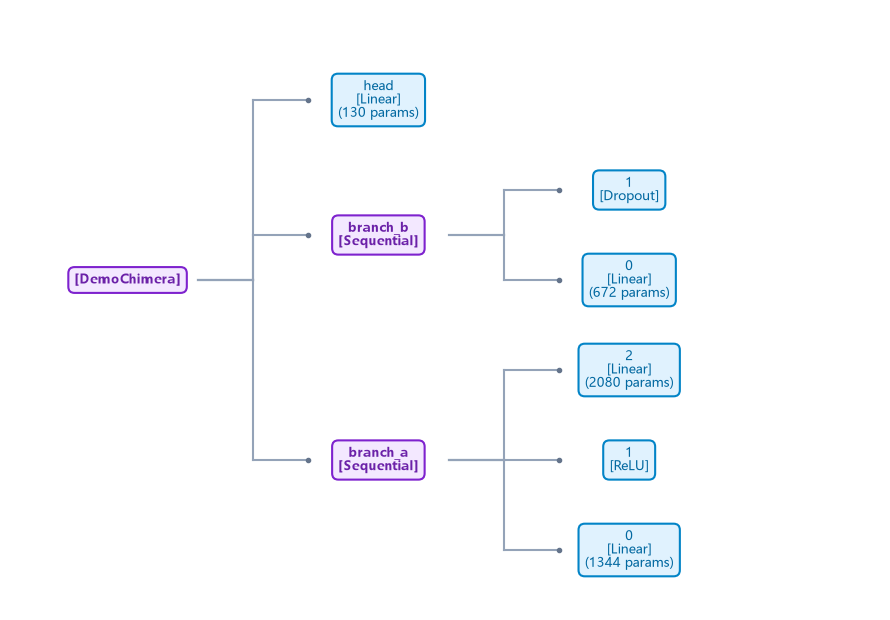

In [16]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# 设置支持中文与负号的字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

class Node:
    def __init__(self, name, module, depth=0):
        self.name = name
        self.module = module
        self.depth = depth
        self.children = []
        self.x = 0.0
        self.y = 0.0

def build_tree(module, name="Root", depth=0):
    node = Node(name, module, depth)
    for c_name, child in module.named_children():
        node.children.append(build_tree(child, c_name, depth + 1))
    return node

def layout_tree(node, cur_y=[0.0], dx=3.0, dy=1.4):
    """自底向上动态计算坐标，彻底防止节点重叠"""
    node.x = node.depth * dx
    if not node.children:
        node.y = cur_y[0]
        cur_y[0] += dy
    else:
        for child in node.children:
            layout_tree(child, cur_y, dx, dy)
        # 父节点的 y 坐标居中于其第一个与最后一个子节点之间
        node.y = (node.children[0].y + node.children[-1].y) / 2.0

def render_tree(node, ax, dx=3.0):
    is_leaf = len(node.children) == 0
    cls_name = type(node.module).__name__
    
    # 统计当前层独有的参数量
    params = sum(p.numel() for p in node.module.parameters(recurse=False))
    param_info = f"\n({params} params)" if params > 0 else ""
    
    # 容器层与执行叶子层应用差异化配色
    if is_leaf:
        fc, ec, text_color = '#E0F2FE', '#0284C7', '#0369A1'  # 浅蓝：具体操作层
    else:
        fc, ec, text_color = '#F3E8FF', '#7E22CE', '#6B21A8'  # 浅紫：容器/父模块

    label = f"{node.name}\n[{cls_name}]{param_info}" if node.depth > 0 else f"[{cls_name}]"
    
    # 绘制节点卡片
    ax.text(
        node.x, node.y, label,
        ha='center', va='center', fontsize=9,
        color=text_color, weight='bold' if not is_leaf else 'normal',
        bbox=dict(boxstyle='round,pad=0.5', facecolor=fc, edgecolor=ec, linewidth=1.5)
    )

    # 绘制正交平滑折线连接（组织架构树风格，避免斜线穿透）
    for child in node.children:
        mid_x = (node.x + child.x) / 2.0
        # 水平引出 -> 垂直并线 -> 水平接入
        ax.plot([node.x + 0.9, mid_x], [node.y, node.y], color='#94A3B8', lw=1.5)
        ax.plot([mid_x, mid_x], [node.y, child.y], color='#94A3B8', lw=1.5)
        ax.plot([mid_x, child.x - 0.9], [child.y, child.y], color='#94A3B8', lw=1.5)
        
        # 子节点连线末端小圆点
        ax.plot(child.x - 0.9, child.y, marker='o', markersize=3, color='#64748B')
        
        render_tree(child, ax, dx)

def plot_module_tree(model, dx=3.2, dy=1.5):
    root = build_tree(model)
    cur_y = [0.0]
    layout_tree(root, cur_y, dx=dx, dy=dy)
    
    # 统计深度与高度自适应计算画布尺寸
    def get_max_depth(node):
        return 0 if not node.children else 1 + max(get_max_depth(c) for c in node.children)
    
    max_depth = get_max_depth(root)
    total_height = cur_y[0]
    
    fig_w = max(9.0, (max_depth + 1) * dx * 0.9)
    fig_h = max(4.5, total_height * 0.7)
    
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    render_tree(root, ax, dx=dx)
    
    # 留白并隐藏坐标轴
    ax.set_xlim(-1.5, (max_depth + 1) * dx)
    ax.set_ylim(-1.0, total_height)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# 构造一个包含嵌套 Sequential 与独立层的测试网络
class DemoChimera(nn.Module):
    def __init__(self):
        super().__init__()
        self.branch_a = nn.Sequential(
            nn.Linear(20, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )
        self.branch_b = nn.Sequential(
            nn.Linear(20, 32),
            nn.Dropout(0.2)
        )
        self.head = nn.Linear(64, 2)

# 传入实例并绘制
model = DemoChimera()
plot_module_tree(model)

### 6. 效率

为什么花这么大篇幅做"块"的抽象？三大理由：

**① 代码清晰**：架构描述与实现统一在 forward 中，新增变量、操作都很直观。

**② 性能**：Python 是解释型语言，且 CPython 有 **GIL（全局解释器锁）**，逐行调度成千上万个小算子时，解释器开销可能反超计算本身。解决思路是"**混合式编程**"：命令式地写模型，第一次运行时记录执行图并编译成底层代码，之后直接跑编译产物。PyTorch 的对应工具：

| 工具 | 方式 | 特点 |
| --- | --- | --- |
| `torch.jit.trace` | 跑一遍示例输入、记录算子轨迹 | 快，但**控制流被固化**（while 只记当时走的分支） |
| `torch.jit.script` | 直接解析 Python 源码 | 保留控制流，但要求代码类型可静态分析 |
| `torch.compile`（2.0+） | 图捕获 + 算子编译融合 | 主流选择，`torch.compile(net)` 即可加速 |

> 警示：`torch.jit.trace` 无法正确处理 `FixedHiddenMLP` 里的 while 循环——轨迹只反映示例输入那一次执行，换个输入结果就错了。**动态控制流要用 `script` 或 `torch.compile`。**

**③ 通用性**：PyTorch 组件可以部署到服务器、移动端、嵌入式设备；块抽象让同一份模型定义跨平台复用。

### 7. 小结

- **块（block）** 是神经网络的基本组合单位：可以表示单层、组件或整个模型，通过**递归组合**搭建任意架构；
- 块由 `nn.Module` 子类实现，核心是 `__init__`（注册子模块 / 参数）+ `forward`（定义计算）；
- `nn.Module` 通过重写 `__setattr__` 自动把子模块登记进 `_modules`（OrderedDict），由此形成 **Module 树**——`parameters()`、`state_dict()`、`.to()`、`.train()/.eval()` 都沿树递归；
- 自定义顺序块只需往 `self._modules` 里塞子模块（键为字符串）；放进普通 list 的层**对 PyTorch 不可见**（参数不进优化器、不进 state_dict）；
- `forward` 是普通 Python 函数：可混合常数张量（`requires_grad=False`）、复用同一层（**权重共享**，梯度自动累加）、使用数据依赖的控制流；
- 嵌套块支持任意深度，参数名沿树路径命名（如 `0.net.0.weight`）；
- 块抽象兼顾清晰、性能（混合式编程 / `torch.compile`）与通用性（跨平台部署）。

### 8. 练习与参考答案

**练习 1**：如果把 `MySequential` 的实现改为用 Python 列表存储模块，会发生什么问题？
答：见上文反面实验 `BadSequential`——前向传播仍能跑，但列表只是普通 Python 容器，其中的层不会出现在 `parameters()` / `state_dict()` 中：优化器拿不到参数（**永远学不到**），保存 / 加载模型时这些权重也会丢失。

**练习 2**：实现一个**并行块**（parallel block）：接收两个块作为输入，输出为二者输出之和。

In [ ]:
class ParallelBlock(nn.Module):
    """并联两个块：forward(X) = net1(X) + net2(X)"""
    def __init__(self, net1, net2):
        super().__init__()
        self.net1 = net1   # 赋值给属性 → 经 __setattr__ 自动注册
        self.net2 = net2

    def forward(self, X):
        return self.net1(X) + self.net2(X)

# 测试：两个输出维度相同的块并联
pb = ParallelBlock(nn.Linear(20, 10),
                   nn.Sequential(nn.Linear(20, 32), nn.ReLU(), nn.Linear(32, 10)))
pb(X).shape

**练习 3**：实现一个工厂函数，从辅助函数返回同一网络块的多个实例（用于批量构建相同结构的层）。

In [ ]:
import copy

def make_blocks(factory, n):
    """工厂函数：用深拷贝得到 n 个结构相同、但参数独立的块实例"""
    template = factory()
    return [copy.deepcopy(template) for _ in range(n)]

blocks = make_blocks(lambda: nn.Linear(20, 20), 3)
nn.Sequential(*blocks)

要点：`copy.deepcopy` 会复制结构与参数值，但**不共享参数**——各实例可独立训练。

> **下一节**：[5.2 参数管理](https://zh-v2.d2l.ai/chapter_deep-learning-computation/parameters.html) —— 模型搭好了，如何访问、初始化、共享与保存它的参数？